<a href="https://colab.research.google.com/github/ettatanuja-cmyk/Neuro-exercise/blob/main/EEG_Prototype_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install mne scipy scikit-learn tensorflow matplotlib pandas numpy

In [ ]:
# ============================================================
# CELL 2: IMPORT REQUIRED LIBRARIES
# ============================================================

import os                                      # Work with folders and files
import numpy as np                             # Numerical calculations
import pandas as pd                            # Tables and data handling
import matplotlib.pyplot as plt                 # Plot EEG signals
import mne                                     # EEG processing

from scipy import signal                       # Signal-processing functions

from sklearn.model_selection import train_test_split  # Train/test split
from sklearn.metrics import (                  # Evaluation metrics
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf                         # Deep-learning framework
from tensorflow.keras import layers, models    # Keras model building

print("All libraries imported successfully!")
print("MNE version:", mne.__version__)
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
MNE version: 1.13.2
TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# CELL 3: DOWNLOAD PHYSIONET EEG FILES
# ============================================================

import os                                      # File and folder operations
import requests                                # Download files from internet

BASE_URL = "https://physionet.org/files/erpbci/1.0.0"
# Base URL of the PhysioNet ERP-based BCI dataset

subjects = ["s01", "s02"]
# Use two subjects for the first prototype

recordings = ["rc01", "rc02", "rc03"]
# Use three recordings from each subject

DATA_DIR = "/content/erpbci"
# Store the downloaded data inside Google Colab

os.makedirs(DATA_DIR, exist_ok=True)
# Create the main dataset folder if it does not already exist

for subject in subjects:
    # Process one subject at a time

    subject_dir = os.path.join(DATA_DIR, subject)
    # Create the subject-specific folder path

    os.makedirs(subject_dir, exist_ok=True)
    # Create the subject folder if it does not exist

    for run in recordings:
        # Download each selected recording

        edf_name = f"{run}.edf"
        # EEG signal file name

        event_name = f"{run}.edf.event"
        # Event annotation file name

        edf_path = os.path.join(subject_dir, edf_name)
        # Complete path for EEG file

        event_path = os.path.join(subject_dir, event_name)
        # Complete path for event file

        edf_url = f"{BASE_URL}/{subject}/{edf_name}"
        # Direct URL of the EEG file

        event_url = f"{BASE_URL}/{subject}/{event_name}"
        # Direct URL of the event file

        if not os.path.exists(edf_path):
            # Download EEG only when it is not already present

            response = requests.get(edf_url)
            # Request EEG file from PhysioNet

            response.raise_for_status()
            # Stop if the download failed

            with open(edf_path, "wb") as file:
                # Open the destination file in binary mode

                file.write(response.content)
                # Save the downloaded EEG file

            print("Downloaded:", subject, edf_name)
            # Show successful EEG download

        else:
            print("Already exists:", subject, edf_name)
            # Avoid downloading the same file again

        if not os.path.exists(event_path):
            # Download event file if it is not already present

            response = requests.get(event_url)
            # Request event file from PhysioNet

            response.raise_for_status()
            # Stop if the download failed

            with open(event_path, "wb") as file:
                # Open event file in binary mode

                file.write(response.content)
                # Save event information

            print("Downloaded:", subject, event_name)
            # Show successful event download

        else:
            print("Already exists:", subject, event_name)
            # Avoid duplicate download

print("\nDataset download completed successfully!")
# Final confirmation

Downloaded: s01 rc01.edf
Downloaded: s01 rc01.edf.event
Downloaded: s01 rc02.edf
Downloaded: s01 rc02.edf.event
Downloaded: s01 rc03.edf
Downloaded: s01 rc03.edf.event
Downloaded: s02 rc01.edf
Downloaded: s02 rc01.edf.event
Downloaded: s02 rc02.edf
Downloaded: s02 rc02.edf.event
Downloaded: s02 rc03.edf
Downloaded: s02 rc03.edf.event

Dataset download completed successfully!


In [ ]:
# ============================================================
# CELL 4: CHECK DOWNLOADED FILES
# ============================================================

for subject in subjects:
    # Check each selected subject

    subject_dir = os.path.join(DATA_DIR, subject)
    # Get subject folder

    print("\nSubject:", subject)
    # Display subject name

    for file_name in sorted(os.listdir(subject_dir)):
        # Go through every file in the subject folder

        file_path = os.path.join(subject_dir, file_name)
        # Create complete file path

        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        # Convert file size from bytes to MB

        print(f"  {file_name} --> {size_mb:.2f} MB")
        # Display file name and size

print("\nAll files checked successfully!")


Subject: s01
  rc01.edf --> 12.64 MB
  rc01.edf.event --> 0.00 MB
  rc02.edf --> 7.42 MB
  rc02.edf.event --> 0.00 MB
  rc03.edf --> 7.70 MB
  rc03.edf.event --> 0.00 MB

Subject: s02
  rc01.edf --> 7.70 MB
  rc01.edf.event --> 0.00 MB
  rc02.edf --> 7.70 MB
  rc02.edf.event --> 0.00 MB
  rc03.edf --> 7.97 MB
  rc03.edf.event --> 0.00 MB

All files checked successfully!


In [ ]:
# ============================================================
# CELL 5: LOAD ONE EEG RECORDING
# ============================================================

file_path = "/content/erpbci/s01/rc01.edf"
# Select the first EEG recording

raw = mne.io.read_raw_edf(
    file_path,
    preload=True,
    verbose=False
)
# Read the EDF EEG file into MNE

print("EEG file loaded successfully!")
# Confirm successful loading

print("\nNumber of channels:", len(raw.ch_names))
# Display number of channels

print("Sampling frequency:", raw.info["sfreq"], "Hz")
# Display original sampling frequency

print("Recording duration:", raw.times[-1], "seconds")
# Display recording duration

print("\nFirst 10 channel names:")
# Heading for channel names

print(raw.ch_names[:10])
# Display first ten channels

EEG file loaded successfully!

Number of channels: 70
Sampling frequency: 2048.0 Hz
Recording duration: 45.99951171875 seconds

First 10 channel names:
['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']


Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


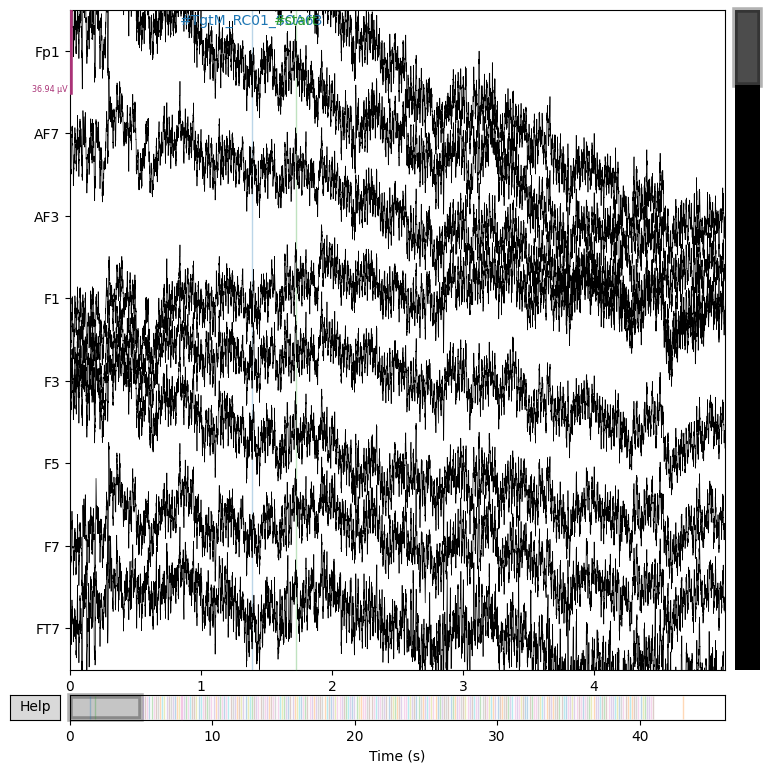

In [ ]:
# ============================================================
# CELL 6: PLOT RAW EEG - BEFORE PREPROCESSING
# ============================================================

raw_copy = raw.copy()
# Make a copy so the original EEG remains unchanged

raw_copy.plot(
    duration=5,
    n_channels=8,
    scalings="auto"
)
# Display the first 8 channels for 5 seconds

plt.show()
# Show the EEG plot

In [ ]:
# ============================================================
# CELL 7: EEG RE-REFERENCING
# ============================================================

raw_reref = raw.copy()
# Create a separate copy

reference_channels = ["EXG1", "EXG2"]
# Try to identify the two external reference channels

available_references = [
    ch for ch in reference_channels if ch in raw_reref.ch_names
]
# Keep only reference channels that actually exist

if len(available_references) == 2:
    # Apply average reference only when both channels exist

    raw_reref.set_eeg_reference(
        ref_channels=available_references,
        projection=False,
        verbose=False
    )
    # Re-reference EEG using the available reference channels

    print("Re-referencing completed.")
    # Confirmation

else:
    print("Reference channels were not found.")
    print("Continuing without re-referencing.")
    # Prevent the notebook from stopping because of channel naming differences

Reference channels were not found.
Continuing without re-referencing.


In [ ]:
# ============================================================
# CELL 8: DOWNSAMPLE EEG TO 120 Hz
# ============================================================

original_fs = raw_reref.info["sfreq"]
# Store the original sampling frequency

print("BEFORE")
print("Sampling frequency:", original_fs, "Hz")
# Display original sampling frequency

raw_downsampled = raw_reref.copy()
# Create a copy before resampling

raw_downsampled.resample(
    120,
    npad="auto",
    verbose=False
)
# Downsample EEG to 120 Hz

new_fs = raw_downsampled.info["sfreq"]
# Store the new sampling frequency

print("\nAFTER")
print("Sampling frequency:", new_fs, "Hz")
# Display new sampling frequency

BEFORE
Sampling frequency: 2048.0 Hz

AFTER
Sampling frequency: 120.0 Hz


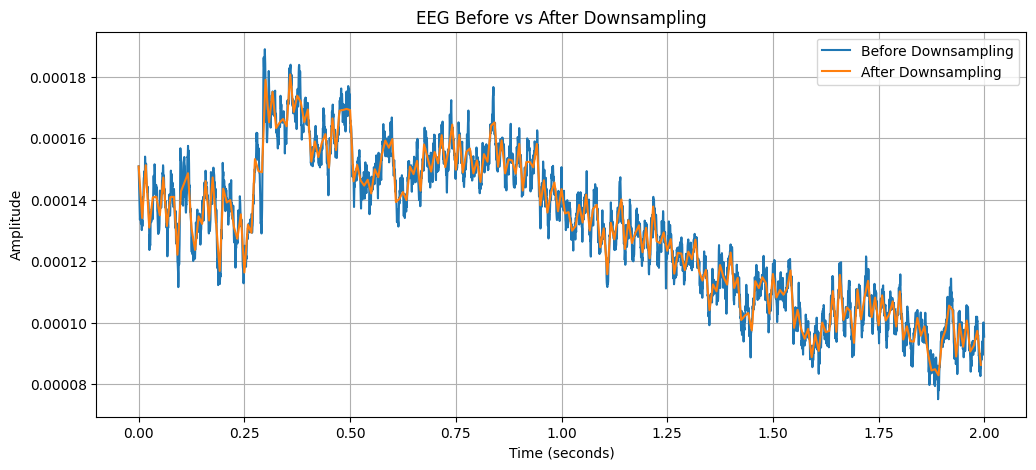

In [ ]:
# ============================================================
# CELL 9: BEFORE VS AFTER DOWNSAMPLING
# ============================================================

channel_index = 0
# Select the first EEG channel

before_data = raw_reref.get_data(
    picks=[channel_index],
    start=0,
    stop=int(original_fs * 2)
)[0]
# Get the first 2 seconds of EEG before downsampling
# [0] selects the first channel from the returned data

after_data = raw_downsampled.get_data(
    picks=[channel_index],
    start=0,
    stop=int(120 * 2)
)[0]
# Get the first 2 seconds of EEG after downsampling
# [0] selects the first channel

before_times = np.arange(len(before_data)) / original_fs
# Create the time axis for the original 2048 Hz signal

after_times = np.arange(len(after_data)) / 120
# Create the time axis for the downsampled 120 Hz signal


plt.figure(figsize=(12, 5))
# Create a figure for the comparison plot

plt.plot(
    before_times,
    before_data,
    label="Before Downsampling"
)
# Plot the original EEG signal

plt.plot(
    after_times,
    after_data,
    label="After Downsampling"
)
# Plot the downsampled EEG signal

plt.xlabel("Time (seconds)")
# Label the X-axis

plt.ylabel("Amplitude")
# Label the Y-axis

plt.title("EEG Before vs After Downsampling")
# Give the graph a meaningful title

plt.legend()
# Display the labels of both signals

plt.grid()
# Add grid lines for easier viewing

plt.show()
# Display the final graph

In [ ]:
# ============================================================
# CELL 10: 1-15 Hz BAND-PASS FILTER
# ============================================================

raw_bandpass = raw_downsampled.copy()
# Create a copy before filtering

print("BEFORE BAND-PASS")
print(
    "Frequency range: approximately 0 to",
    raw_bandpass.info["sfreq"] / 2,
    "Hz"
)
# Display the available frequency range

raw_bandpass.filter(
    l_freq=1.0,
    h_freq=15.0,
    method="iir",
    iir_params={
        "order": 6,
        "ftype": "butter"
    },
    verbose=False
)
# Apply sixth-order Butterworth 1-15 Hz band-pass filter

print("\nAFTER BAND-PASS")
print("Band-pass range: 1-15 Hz")
print("Filter order: 6")
print("Filter type: Butterworth")
# Display filtering information

BEFORE BAND-PASS
Frequency range: approximately 0 to 60.0 Hz

AFTER BAND-PASS
Band-pass range: 1-15 Hz
Filter order: 6
Filter type: Butterworth


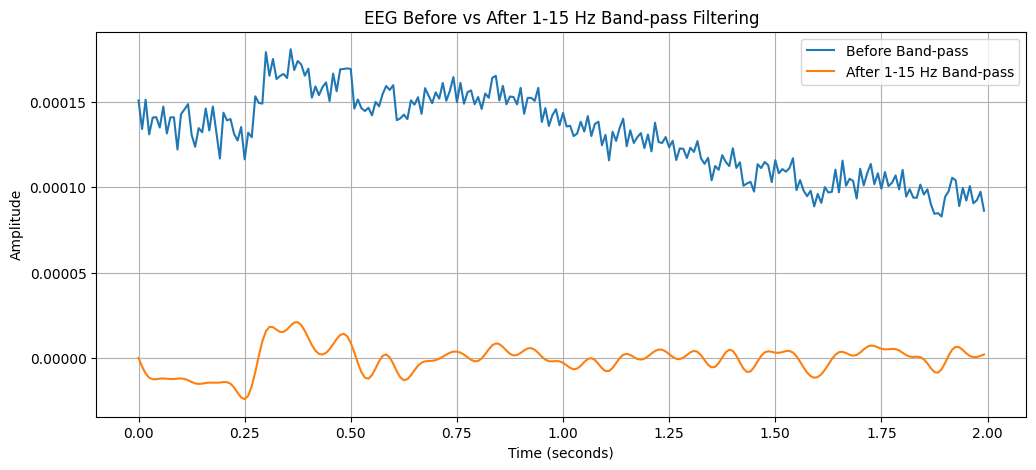

In [ ]:
# ============================================================
# CELL 11: BEFORE VS AFTER BAND-PASS FILTER
# ============================================================

before_filter = raw_downsampled.get_data(
    picks=[0],
    start=0,
    stop=240
)[0]
# Get first 2 seconds before filtering

after_filter = raw_bandpass.get_data(
    picks=[0],
    start=0,
    stop=240
)[0]
# Get first 2 seconds after filtering

time_axis = np.arange(240) / 120
# Create time axis for 120 Hz sampling

plt.figure(figsize=(12, 5))
# Create plot

plt.plot(
    time_axis,
    before_filter,
    label="Before Band-pass"
)
# Plot signal before filtering

plt.plot(
    time_axis,
    after_filter,
    label="After 1-15 Hz Band-pass"
)
# Plot filtered signal

plt.xlabel("Time (seconds)")
# X-axis label

plt.ylabel("Amplitude")
# Y-axis label

plt.title("EEG Before vs After 1-15 Hz Band-pass Filtering")
# Plot title

plt.legend()
# Display legend

plt.grid()
# Add grid

plt.show()
# Display figure

In [ ]:
# ============================================================
# CELL 12: NOTCH FILTER
# ============================================================

raw_notch = raw_bandpass.copy()
# Create a copy before notch filtering

print("BEFORE NOTCH FILTER")
# Display stage name

raw_notch.notch_filter(
    freqs=50,
    method="iir",
    verbose=False
)
# Remove 50 Hz power-line interference

print("AFTER NOTCH FILTER")
print("Notch frequency: 50 Hz")
print("Notch filtering completed successfully.")
# Display completion information

BEFORE NOTCH FILTER
AFTER NOTCH FILTER
Notch frequency: 50 Hz
Notch filtering completed successfully.


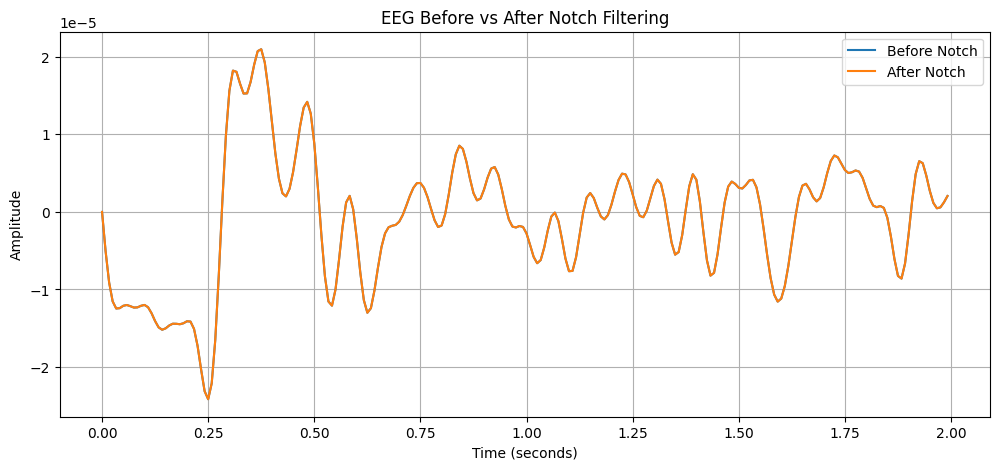

In [ ]:
# ============================================================
# CELL 13: BEFORE VS AFTER NOTCH FILTER
# ============================================================

before_notch = raw_bandpass.get_data(
    picks=[0],
    start=0,
    stop=240
)[0]
# Get signal before notch filtering

after_notch = raw_notch.get_data(
    picks=[0],
    start=0,
    stop=240
)[0]
# Get signal after notch filtering

time_axis = np.arange(240) / 120
# Create time axis

plt.figure(figsize=(12, 5))
# Create figure

plt.plot(
    time_axis,
    before_notch,
    label="Before Notch"
)
# Plot before notch

plt.plot(
    time_axis,
    after_notch,
    label="After Notch"
)
# Plot after notch

plt.xlabel("Time (seconds)")
# X-axis label

plt.ylabel("Amplitude")
# Y-axis label

plt.title("EEG Before vs After Notch Filtering")
# Plot title

plt.legend()
# Display legend

plt.grid()
# Add grid

plt.show()
# Display plot

In [ ]:
# ============================================================
# CELL 14: WINSORIZATION
# ============================================================

def winsorize_array(data, lower=1, upper=99):
    # Define a function to limit extreme EEG values

    low_limit = np.percentile(data, lower)
    # Calculate lower percentile

    high_limit = np.percentile(data, upper)
    # Calculate upper percentile

    return np.clip(
        data,
        low_limit,
        high_limit
    )
    # Replace extreme values with percentile limits


before_winsor = raw_notch.get_data()
# Get EEG data before Winsorization

after_winsor = winsorize_array(
    before_winsor,
    lower=1,
    upper=99
)
# Apply 1st-99th percentile Winsorization

print("BEFORE WINSORIZATION")
print("Minimum:", before_winsor.min())
print("Maximum:", before_winsor.max())
# Display original range

print("\nAFTER WINSORIZATION")
print("Minimum:", after_winsor.min())
print("Maximum:", after_winsor.max())
# Display new range

BEFORE WINSORIZATION
Minimum: -5.074847927749665e-05
Maximum: 0.00018260823496667297

AFTER WINSORIZATION
Minimum: -1.3369815831350616e-05
Maximum: 1.3159211059195425e-05


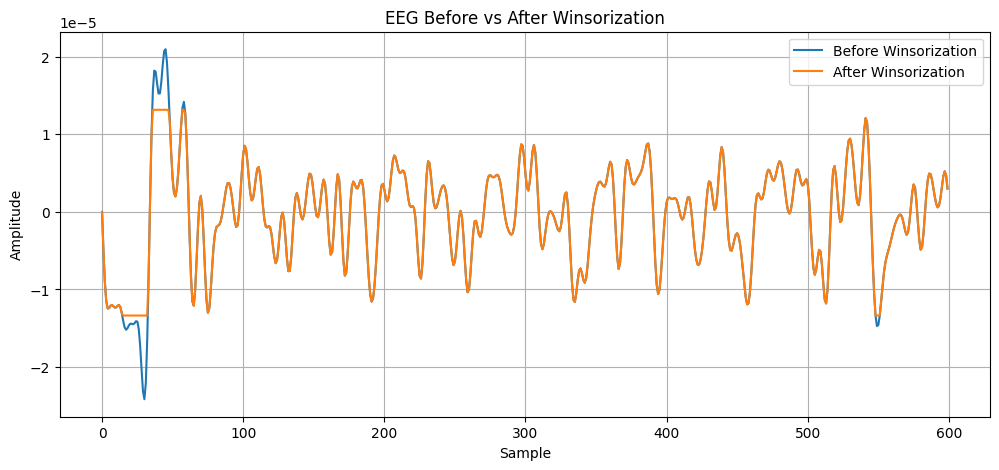

In [ ]:
# ============================================================
# CELL 15: BEFORE VS AFTER WINSORIZATION
# ============================================================

plt.figure(figsize=(12, 5))
# Create figure

plt.plot(
    before_winsor[0, :600],
    label="Before Winsorization"
)
# Plot original EEG values

plt.plot(
    after_winsor[0, :600],
    label="After Winsorization"
)
# Plot Winsorized EEG values

plt.xlabel("Sample")
# X-axis label

plt.ylabel("Amplitude")
# Y-axis label

plt.title("EEG Before vs After Winsorization")
# Plot title

plt.legend()
# Show legend

plt.grid()
# Add grid

plt.show()
# Display plot

In [ ]:
# ============================================================
# CELL 16: CREATE CLEANED EEG DATA
# ============================================================

cleaned_raw = raw_notch.copy()
# Copy the filtered EEG object

cleaned_data = after_winsor
# Store the Winsorized data

cleaned_raw._data = cleaned_data
# Replace raw data with Winsorized values

print("Cleaned EEG created successfully!")
# Confirmation

print("Channels:", len(cleaned_raw.ch_names))
# Display channel count

print("Sampling frequency:", cleaned_raw.info["sfreq"])
# Display final sampling frequency

Cleaned EEG created successfully!
Channels: 70
Sampling frequency: 120.0


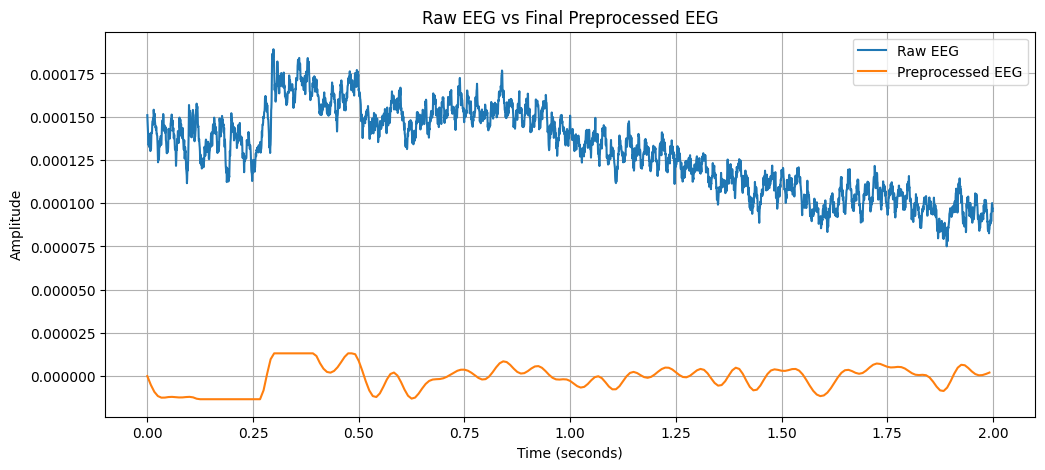

In [ ]:
# ============================================================
# CELL 17: RAW VS FINAL PREPROCESSED EEG
# ============================================================

raw_signal = raw.get_data(
    picks=[0],
    start=0,
    stop=int(original_fs * 2)
)[0]
# Get first 2 seconds of original EEG

final_signal = cleaned_raw.get_data(
    picks=[0],
    start=0,
    stop=240
)[0]
# Get first 2 seconds of processed EEG

raw_time = np.arange(len(raw_signal)) / original_fs
# Time axis for raw signal

final_time = np.arange(len(final_signal)) / 120
# Time axis for processed signal

plt.figure(figsize=(12, 5))
# Create figure

plt.plot(
    raw_time,
    raw_signal,
    label="Raw EEG"
)
# Plot original EEG

plt.plot(
    final_time,
    final_signal,
    label="Preprocessed EEG"
)
# Plot processed EEG

plt.xlabel("Time (seconds)")
# X-axis label

plt.ylabel("Amplitude")
# Y-axis label

plt.title("Raw EEG vs Final Preprocessed EEG")
# Plot title

plt.legend()
# Display legend

plt.grid()
# Display grid

plt.show()
# Show plot

In [ ]:
# ============================================================
# CELL 18: READ P300 EVENT ANNOTATIONS
# ============================================================

events_from_annotations = mne.events_from_annotations(
    raw,
    verbose=False
)
# Extract annotation events from the original EEG

event_array = events_from_annotations[0]
# Store event sample positions and event IDs

event_dictionary = events_from_annotations[1]
# Store annotation-to-ID mapping

print("Number of detected annotations:", len(event_array))
# Display number of events

print("\nAnnotation dictionary:")
print(event_dictionary)
# Display all annotation descriptions

Number of detected annotations: 243

Annotation dictionary:
{'#TgtM_RC01_SOA63': 1, '#end': 2, '#start': 3, '56789_': 4, 'ABCDEF': 5, 'AGMSY5': 6, 'BHNTZ6': 7, 'CIOU17': 8, 'DJPV28': 9, 'EKQW39': 10, 'FLRX4_': 11, 'GHIJKL': 12, 'MNOPQR': 13, 'STUVWX': 14, 'YZ1234': 15}


In [ ]:
# ============================================================
# CELL 19: DISPLAY EVENT INFORMATION
# ============================================================

print("First 20 event entries:")
# Heading

print(event_array[:20])
# Display first 20 event rows

print("\nNumber of unique event types:")
print(len(event_dictionary))
# Display number of event types

First 20 event entries:
[[ 2840     0     1]
 [ 3528     0     3]
 [10511     0    13]
 [10818     0    14]
 [11125     0    15]
 [11432     0    10]
 [11739     0    12]
 [12046     0     6]
 [12354     0     5]
 [12661     0     7]
 [12968     0    11]
 [13273     0     9]
 [13580     0     8]
 [13887     0     4]
 [14194     0    14]
 [14502     0     7]
 [14809     0    13]
 [15116     0    10]
 [15423     0    11]
 [15730     0     8]]

Number of unique event types:
15


In [ ]:
# ============================================================
# CELL 20: READ THE ORIGINAL EVENT FILE
# ============================================================

event_file = "/content/erpbci/s01/rc01.edf.event"
# Select the event file corresponding to our EEG recording

with open(event_file, "r", encoding="latin-1") as file:
    # Open the event file using latin-1 encoding
    # latin-1 can read byte values that UTF-8 cannot decode

    event_lines = file.readlines()
    # Read all event lines from the file


print("Number of event lines:", len(event_lines))
# Display the total number of event lines


print("\nFirst 15 event lines:\n")
# Display a heading


for line in event_lines[:15]:
    # Go through the first 15 event lines

    print(line.strip())
    # Remove extra spaces/newline characters and display the event

Number of event lines: 1

First 15 event lines:

 Xü## time resolution: 2048 ìÿÿÿÿ  ì   Xü#TgtM_RC01_SOA63°Zü#start ì  G XüMNOPQR3YüSTUVWX3YüYZ12343YüEKQW393YüGHIJKL3YüAGMSY54YüABCDEF3YüBHNTZ63YüFLRX4_1YüDJPV283YüCIOU173Yü56789_3YüSTUVWX4YüBHNTZ63YüMNOPQR3YüEKQW393YüFLRX4_3YüCIOU173YüAGMSY54Yü56789_3YüGHIJKL3YüYZ12343YüDJPV283YüABCDEF3YüABCDEF3YüCIOU174YüEKQW393YüDJPV283YüAGMSY53YüSTUVWX3YüGHIJKL3YüBHNTZ64YüYZ12343Yü56789_3YüFLRX4_3YüMNOPQR3YüGHIJKL3YüYZ12343YüEKQW394YüAGMSY53YüDJPV283YüSTUVWX3YüBHNTZ61YüMNOPQR3YüFLRX4_3YüABCDEF4YüCIOU173Yü56789_3YüEKQW393YüCIOU173YüDJPV283YüGHIJKL6YüABCDEF1Yü56789_3YüYZ12343YüSTUVWX3YüBHNTZ63YüAGMSY53YüMNOPQR4YüFLRX4_3YüSTUVWX3YüAGMSY53YüBHNTZ63YüYZ12343YüDJPV284YüCIOU173YüGHIJKL3Yü56789_3YüEKQW393YüABCDEF3YüMNOPQR3YüFLRX4_4YüCIOU173YüDJPV283YüEKQW393YüYZ12341YüGHIJKL3YüSTUVWX4YüAGMSY53YüMNOPQR3YüFLRX4_3Yü56789_3YüBHNTZ63YüABCDEF3YüBHNTZ64YüFLRX4_3YüDJPV283Y

In [ ]:
# ============================================================
# CELL 21: CREATE EVENT REFERENCE TABLE
# ============================================================

event_table = pd.DataFrame({
    "Raw_Event": [line.strip() for line in event_lines]
})
# Store every event line in a DataFrame

print(event_table.head(15).to_string(index=False))
# Display first 15 events as a table

In [ ]:
# ============================================================
# CELL 22: IDENTIFY TARGET CHARACTER
# ============================================================

target_line = None
# Variable to store the target annotation

for line in event_lines:
    # Check every event line

    if "#Tgt" in line:
        # Look for the target annotation

        target_line = line.strip()
        # Save the target annotation

        break
        # Stop after finding the first target


print("Target annotation:")
print(target_line)
# Display target information

Target annotation:
 Xü## time resolution: 2048 ìÿÿÿÿ  ì   Xü#TgtM_RC01_SOA63°Zü#start ì  G XüMNOPQR3YüSTUVWX3YüYZ12343YüEKQW393YüGHIJKL3YüAGMSY54YüABCDEF3YüBHNTZ63YüFLRX4_1YüDJPV283YüCIOU173Yü56789_3YüSTUVWX4YüBHNTZ63YüMNOPQR3YüEKQW393YüFLRX4_3YüCIOU173YüAGMSY54Yü56789_3YüGHIJKL3YüYZ12343YüDJPV283YüABCDEF3YüABCDEF3YüCIOU174YüEKQW393YüDJPV283YüAGMSY53YüSTUVWX3YüGHIJKL3YüBHNTZ64YüYZ12343Yü56789_3YüFLRX4_3YüMNOPQR3YüGHIJKL3YüYZ12343YüEKQW394YüAGMSY53YüDJPV283YüSTUVWX3YüBHNTZ61YüMNOPQR3YüFLRX4_3YüABCDEF4YüCIOU173Yü56789_3YüEKQW393YüCIOU173YüDJPV283YüGHIJKL6YüABCDEF1Yü56789_3YüYZ12343YüSTUVWX3YüBHNTZ63YüAGMSY53YüMNOPQR4YüFLRX4_3YüSTUVWX3YüAGMSY53YüBHNTZ63YüYZ12343YüDJPV284YüCIOU173YüGHIJKL3Yü56789_3YüEKQW393YüABCDEF3YüMNOPQR3YüFLRX4_4YüCIOU173YüDJPV283YüEKQW393YüYZ12341YüGHIJKL3YüSTUVWX4YüAGMSY53YüMNOPQR3YüFLRX4_3Yü56789_3YüBHNTZ63YüABCDEF3YüBHNTZ64YüFLRX4_3YüDJPV283YüABCDEF3YüEKQW393YüMNOPQR3Y

In [ ]:
# ============================================================
# CELL 23: EXTRACT TARGET CHARACTER
# ============================================================

if target_line is not None:
    # Continue only if a target annotation was found

    target_text = target_line.split("#Tgt")[1]
    # Remove the "#Tgt" prefix

    target_character = target_text[0]
    # The first character is the target character

    print("Target character:", target_character)
    # Display target character

else:
    # Handle missing target annotation

    target_character = None
    # Store missing value

    print("Target character was not found.")
    # Display warning

Target character: M


In [ ]:
# ============================================================
# CELL 24: TARGET / NON-TARGET LABEL LOGIC
# ============================================================

def get_target_label(flashed_characters, target_character):
    # Define a function for target classification

    if target_character is None:
        # Check whether a target exists

        return None
        # Cannot classify without target

    if target_character in flashed_characters:
        # Check whether target character was in the flashed set

        return 1
        # 1 means TARGET

    return 0
    # 0 means NON-TARGET


print("Target label function created successfully!")
# Confirmation

Target label function created successfully!


In [ ]:
# ============================================================
# CELL 25: TARGET / NON-TARGET REFERENCE TABLE
# ============================================================

reference_table = pd.DataFrame({
    "Condition": [
        "Flashed set contains target character",
        "Flashed set does not contain target character"
    ],
    "Label": [
        1,
        0
    ],
    "Meaning": [
        "TARGET / P300 expected",
        "NON-TARGET"
    ]
})
# Create a reference table

display(reference_table)
# Display the table

,Condition,Label,Meaning
0,Flashed set contains target character,1,TARGET / P300 expected
1,Flashed set does not contain target character,0,NON-TARGET


In [ ]:
# ============================================================
# CELL 26: CREATE STIMULUS TABLE FROM MNE ANNOTATIONS
# ============================================================

# Create an empty list to store stimulus information
stimulus_records = []

# Go through every annotation in the EEG recording
for onset, description in zip(
    raw.annotations.onset,
    raw.annotations.description
):

    # Ignore special annotations such as #Tgt, #start and #end
    if description.startswith("#"):
        continue

    # Store the stimulus information
    stimulus_records.append({
        "onset": onset,                       # Stimulus time in seconds
        "flashed_characters": description     # Characters flashed on screen
    })

# Convert the list into a pandas DataFrame
stimulus_df = pd.DataFrame(stimulus_records)

# Add target/non-target labels
stimulus_df["label"] = stimulus_df["flashed_characters"].apply(
    lambda x: get_target_label(x, target_character)
)

# Display the first 10 stimulus events
display(stimulus_df.head(10))

# Print basic information
print("Total stimulus events:", len(stimulus_df))
print("Target character:", target_character)

,onset,flashed_characters,label
0,5.1323,MNOPQR,1
1,5.2822,STUVWX,0
2,5.4321,YZ1234,0
3,5.5820,EKQW39,0
4,5.7319,GHIJKL,0
5,5.8818,AGMSY5,1
6,6.0322,ABCDEF,0
7,6.1821,BHNTZ6,0
8,6.3320,FLRX4_,0
9,6.4809,DJPV28,0


Total stimulus events: 240
Target character: M


In [ ]:
# ============================================================
# CELL 26: EXTRACT TARGET AND STIMULUS GROUPS FROM EVENT DATA
# ============================================================

import re

# Combine all event data into one string
event_text = "\n".join(event_lines)

# ------------------------------------------------------------
# FIND TARGET CHARACTER
# ------------------------------------------------------------

# Search for patterns such as:
# #TgtM_RC01_SOA63
target_match = re.search(
    r"#Tgt([A-Z0-9_])_",
    event_text
)

# Check whether the target was found
if target_match:

    # Extract the target character
    detected_target = target_match.group(1)

    print("Detected target character:", detected_target)

else:

    detected_target = None

    print("Target character was not found.")


# ------------------------------------------------------------
# EXTRACT STIMULUS GROUPS
# ------------------------------------------------------------

# Define the expected valid character groups
valid_groups = [
    "ABCDEF",
    "GHIJKL",
    "MNOPQR",
    "STUVWX",
    "YZ1234",
    "56789_",
    "AGMSY5",
    "BHNTZ6",
    "CIOU17",
    "DJPV28",
    "EKQW39",
    "FLRX4_"
]

# Create empty list for extracted stimuli
extracted_stimuli = []

# Search for every valid group in the binary event data
for group in valid_groups:

    # Find all occurrences of this group
    matches = re.findall(
        group,
        event_text
    )

    # Add every occurrence
    extracted_stimuli.extend(matches)


# Print results
print("\nTotal extracted stimulus groups:",
      len(extracted_stimuli))

print("\nFirst 30 stimulus groups:")
print(extracted_stimuli[:30])

Detected target character: M

Total extracted stimulus groups: 240

First 30 stimulus groups:
['ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'ABCDEF', 'GHIJKL', 'GHIJKL', 'GHIJKL', 'GHIJKL', 'GHIJKL', 'GHIJKL', 'GHIJKL', 'GHIJKL', 'GHIJKL', 'GHIJKL']


In [ ]:
# ============================================================
# CELL 27: EXTRACT STIMULI IN ORIGINAL PRESENTATION ORDER
# ============================================================

# Create one regular expression containing all valid groups
stimulus_pattern = (
    r"ABCDEF|GHIJKL|MNOPQR|STUVWX|YZ1234|56789_|"
    r"AGMSY5|BHNTZ6|CIOU17|DJPV28|EKQW39|FLRX4_"
)

# Find all groups while preserving their original order
ordered_stimuli = re.findall(
    stimulus_pattern,
    event_text
)

# Print number of extracted events
print("Total ordered stimulus events:",
      len(ordered_stimuli))

# Display first 30 events
print("\nFirst 30 events:")
print(ordered_stimuli[:30])

Total ordered stimulus events: 240

First 30 events:
['MNOPQR', 'STUVWX', 'YZ1234', 'EKQW39', 'GHIJKL', 'AGMSY5', 'ABCDEF', 'BHNTZ6', 'FLRX4_', 'DJPV28', 'CIOU17', '56789_', 'STUVWX', 'BHNTZ6', 'MNOPQR', 'EKQW39', 'FLRX4_', 'CIOU17', 'AGMSY5', '56789_', 'GHIJKL', 'YZ1234', 'DJPV28', 'ABCDEF', 'ABCDEF', 'CIOU17', 'EKQW39', 'DJPV28', 'AGMSY5', 'STUVWX']


In [ ]:
# ============================================================
# CELL 28: SELECT EEG CHANNELS
# ============================================================

# Get all channel names from the preprocessed EEG
all_channels = cleaned_raw.ch_names

# Select only channels whose type is EEG
eeg_picks = mne.pick_types(
    cleaned_raw.info,
    eeg=True,
    eog=False,
    exclude=[]
)

# Get the names of the selected EEG channels
eeg_channel_names = [
    cleaned_raw.ch_names[i]
    for i in eeg_picks
]

# Print the number of EEG channels
print("Number of EEG channels:", len(eeg_channel_names))

# Print the first few channel names
print("First EEG channels:")
print(eeg_channel_names[:10])

Number of EEG channels: 70
First EEG channels:
['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']


In [ ]:
# ============================================================
# CELL 29: EXTRACT P300 EPOCHS
# ============================================================

# EEG sampling frequency after downsampling
sfreq = cleaned_raw.info["sfreq"]

# Define epoch start time
tmin = 0.0

# Define epoch end time
tmax = 1.0

# Convert EEG data into NumPy array
eeg_data = cleaned_raw.get_data(
    picks=eeg_picks
)

# Create empty lists for epochs and labels
epochs_list = []
labels_list = []

# Loop through every stimulus event
for _, event in stimulus_df.iterrows():

    # Get stimulus sample number
    sample = int(event["onset"] * sfreq)

    # Convert sample number into EEG array index
    start_sample = sample

    # Calculate number of samples for 1 second
    epoch_length = int(sfreq * (tmax - tmin))

    # Calculate ending sample
    end_sample = start_sample + epoch_length

    # Make sure epoch does not go outside EEG recording
    if end_sample > eeg_data.shape[1]:
        continue

    # Extract EEG segment
    epoch = eeg_data[
        :,
        start_sample:end_sample
    ]

    # Store the epoch
    epochs_list.append(epoch)

    # Store corresponding TARGET/NON-TARGET label
    labels_list.append(int(event["label"]))

# Convert lists into NumPy arrays
X = np.array(epochs_list)
y = np.array(labels_list)

# Print resulting shapes
print("Epoch data shape:", X.shape)
print("Labels shape:", y.shape)

Epoch data shape: (240, 70, 120)
Labels shape: (240,)


In [ ]:
# ============================================================
# DEBUG CELL: CHECK MNE ANNOTATIONS
# ============================================================

# Display the annotations stored inside the EDF
print("Number of annotations:", len(raw.annotations))

# Print the first 30 annotations
for i in range(min(30, len(raw.annotations))):

    print(
        i,
        "Onset =", raw.annotations.onset[i],
        "Duration =", raw.annotations.duration[i],
        "Description =", repr(raw.annotations.description[i])
    )

Number of annotations: 243
0 Onset = 1.3867 Duration = 0.0 Description = '#TgtM_RC01_SOA63'
1 Onset = 1.7226 Duration = 0.0 Description = '#start'
2 Onset = 5.1323 Duration = 0.0 Description = 'MNOPQR'
3 Onset = 5.2822 Duration = 0.0 Description = 'STUVWX'
4 Onset = 5.4321 Duration = 0.0 Description = 'YZ1234'
5 Onset = 5.582 Duration = 0.0 Description = 'EKQW39'
6 Onset = 5.7319 Duration = 0.0 Description = 'GHIJKL'
7 Onset = 5.8818 Duration = 0.0 Description = 'AGMSY5'
8 Onset = 6.0322 Duration = 0.0 Description = 'ABCDEF'
9 Onset = 6.1821 Duration = 0.0 Description = 'BHNTZ6'
10 Onset = 6.332 Duration = 0.0 Description = 'FLRX4_'
11 Onset = 6.4809 Duration = 0.0 Description = 'DJPV28'
12 Onset = 6.6308 Duration = 0.0 Description = 'CIOU17'
13 Onset = 6.7807 Duration = 0.0 Description = '56789_'
14 Onset = 6.9306 Duration = 0.0 Description = 'STUVWX'
15 Onset = 7.081 Duration = 0.0 Description = 'BHNTZ6'
16 Onset = 7.2309 Duration = 0.0 Description = 'MNOPQR'
17 Onset = 7.3808 Durati

In [ ]:
# ============================================================
# CELL 26: CREATE STIMULUS TABLE FROM MNE ANNOTATIONS
# ============================================================

# Create an empty list to store stimulus information
stimulus_records = []

# Go through every annotation in the EEG recording
for onset, description in zip(
    raw.annotations.onset,
    raw.annotations.description
):

    # Ignore special annotations such as #Tgt, #start and #end
    if description.startswith("#"):
        continue

    # Store the stimulus information
    stimulus_records.append({
        "onset": onset,                       # Stimulus time in seconds
        "flashed_characters": description     # Characters flashed on screen
    })

# Convert the list into a pandas DataFrame
stimulus_df = pd.DataFrame(stimulus_records)

# Add target/non-target labels
stimulus_df["label"] = stimulus_df["flashed_characters"].apply(
    lambda x: get_target_label(x, target_character)
)

# Display the first 10 stimulus events
display(stimulus_df.head(10))

# Print basic information
print("Total stimulus events:", len(stimulus_df))
print("Target character:", target_character)

,onset,flashed_characters,label
0,5.1323,MNOPQR,1
1,5.2822,STUVWX,0
2,5.4321,YZ1234,0
3,5.5820,EKQW39,0
4,5.7319,GHIJKL,0
5,5.8818,AGMSY5,1
6,6.0322,ABCDEF,0
7,6.1821,BHNTZ6,0
8,6.3320,FLRX4_,0
9,6.4809,DJPV28,0


Total stimulus events: 240
Target character: M


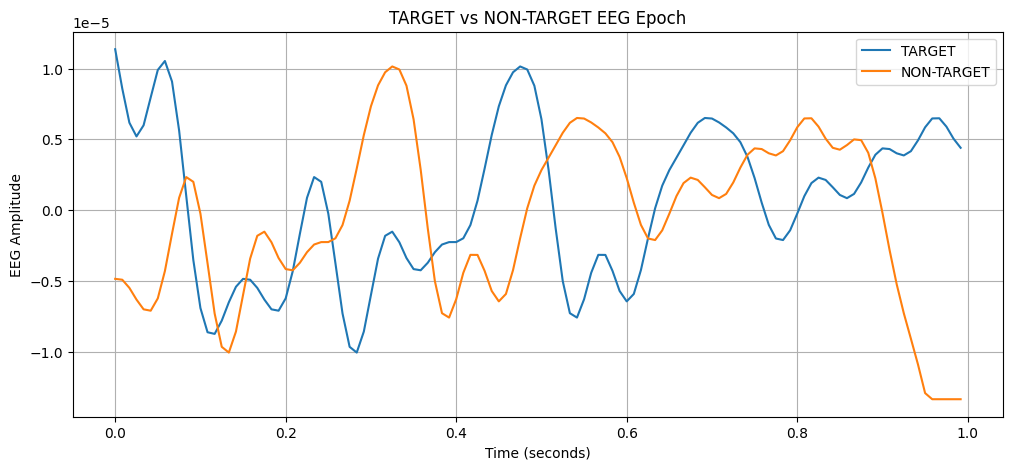

In [ ]:
# ============================================================
# CELL 31: TARGET VS NON-TARGET EEG
# ============================================================

# Find first TARGET epoch
target_indices = np.where(y == 1)[0]

# Find first NON-TARGET epoch
non_target_indices = np.where(y == 0)[0]

# Check that both classes exist
if len(target_indices) == 0 or len(non_target_indices) == 0:

    print("Both classes are not available.")

else:

    # Select one TARGET epoch
    target_epoch = X[target_indices[0]]

    # Select one NON-TARGET epoch
    non_target_epoch = X[non_target_indices[0]]

    # Select first EEG channel
    channel = 0

    # Create time axis
    time_axis = np.arange(X.shape[2]) / sfreq

    # Plot TARGET signal
    plt.figure(figsize=(12, 5))

    plt.plot(
        time_axis,
        target_epoch[channel],
        label="TARGET"
    )

    plt.plot(
        time_axis,
        non_target_epoch[channel],
        label="NON-TARGET"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("EEG Amplitude")
    plt.title("TARGET vs NON-TARGET EEG Epoch")
    plt.legend()
    plt.grid()

    plt.show()

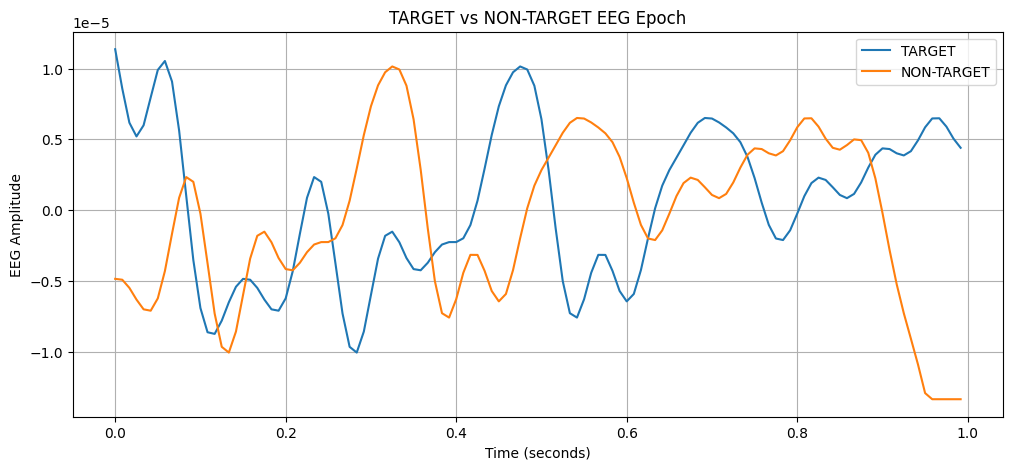

In [ ]:
# ============================================================
# CELL 31: TARGET VS NON-TARGET EEG
# ============================================================

# Find first TARGET epoch
target_indices = np.where(y == 1)[0]

# Find first NON-TARGET epoch
non_target_indices = np.where(y == 0)[0]

# Check that both classes exist
if len(target_indices) == 0 or len(non_target_indices) == 0:

    print("Both classes are not available.")

else:

    # Select one TARGET epoch
    target_epoch = X[target_indices[0]]

    # Select one NON-TARGET epoch
    non_target_epoch = X[non_target_indices[0]]

    # Select first EEG channel
    channel = 0

    # Create time axis
    time_axis = np.arange(X.shape[2]) / sfreq

    # Plot TARGET signal
    plt.figure(figsize=(12, 5))

    plt.plot(
        time_axis,
        target_epoch[channel],
        label="TARGET"
    )

    plt.plot(
        time_axis,
        non_target_epoch[channel],
        label="NON-TARGET"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("EEG Amplitude")
    plt.title("TARGET vs NON-TARGET EEG Epoch")
    plt.legend()
    plt.grid()

    plt.show()

In [ ]:
# ============================================================
# CELL 32: TRAIN / TEST SPLIT BEFORE NORMALIZATION
# ============================================================

# Split the EEG epochs into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Print the resulting shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (192, 70, 120)
X_test : (48, 70, 120)
y_train: (192,)
y_test : (48,)


In [ ]:
# ============================================================
# CELL 33: EEG NORMALIZATION
# ============================================================

# Calculate mean using ONLY training data
train_mean = np.mean(
    X_train,
    axis=(0, 2),
    keepdims=True
)

# Calculate standard deviation using ONLY training data
train_std = np.std(
    X_train,
    axis=(0, 2),
    keepdims=True
)

# Avoid division by zero
train_std[train_std == 0] = 1

# Normalize training data
X_train_norm = (
    X_train - train_mean
) / train_std

# Normalize test data using training statistics
X_test_norm = (
    X_test - train_mean
) / train_std

# Print results
print("Training normalized mean:",
      np.mean(X_train_norm))

print("Training normalized standard deviation:",
      np.std(X_train_norm))

Training normalized mean: 3.912214467726742e-18
Training normalized standard deviation: 0.9999999999999998


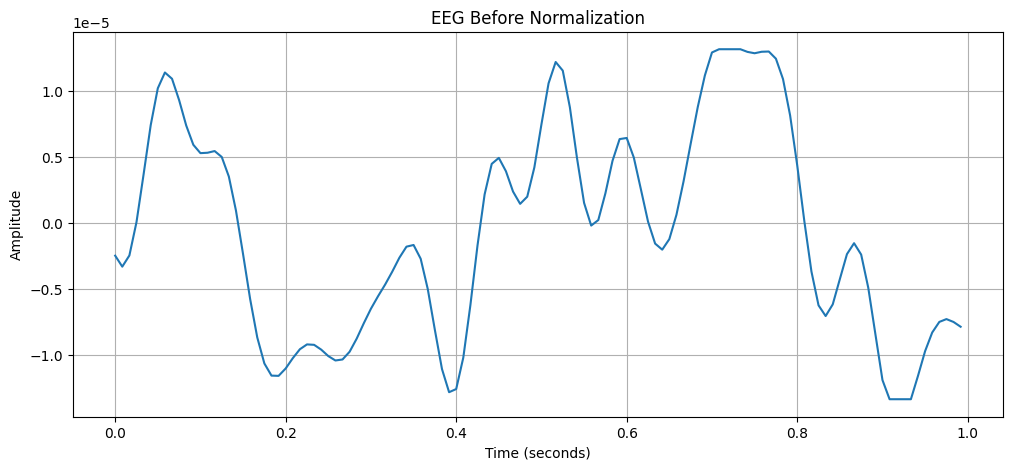

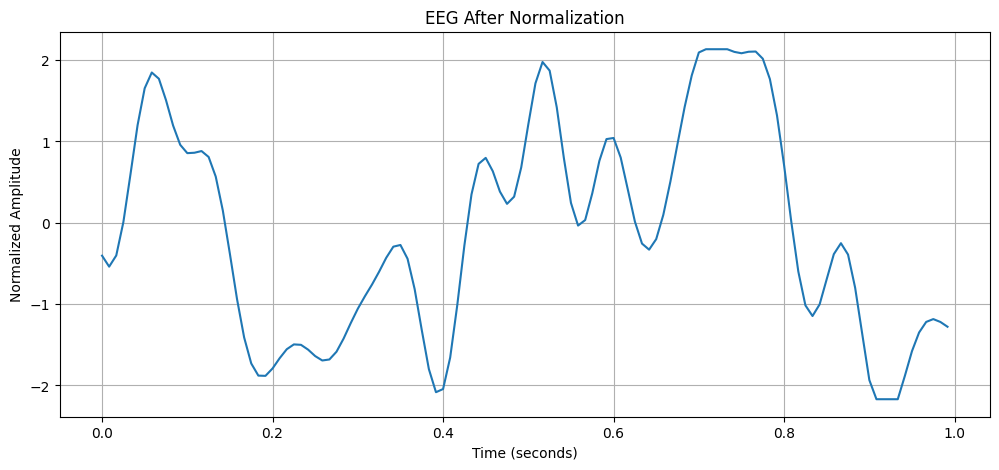

In [ ]:
# ============================================================
# CELL 34: BEFORE / AFTER NORMALIZATION
# ============================================================

# Select one training epoch
sample_epoch_before = X_train[0]

# Select its normalized version
sample_epoch_after = X_train_norm[0]

# Select first channel
channel = 0

# Create time axis
time_axis = np.arange(X_train.shape[2]) / sfreq

# Plot before normalization
plt.figure(figsize=(12, 5))

plt.plot(
    time_axis,
    sample_epoch_before[channel]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("EEG Before Normalization")

plt.grid()
plt.show()

# Plot after normalization
plt.figure(figsize=(12, 5))

plt.plot(
    time_axis,
    sample_epoch_after[channel]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title("EEG After Normalization")

plt.grid()
plt.show()

In [ ]:
# ============================================================
# CELL 35: BALANCE TRAINING DATA
# ============================================================

# Find indices of NON-TARGET training samples
class_0_indices = np.where(y_train == 0)[0]

# Find indices of TARGET training samples
class_1_indices = np.where(y_train == 1)[0]

# Find smaller class size
minimum_class_size = min(
    len(class_0_indices),
    len(class_1_indices)
)

# Random generator for reproducibility
rng = np.random.default_rng(42)

# Randomly select equal number of samples from class 0
selected_0 = rng.choice(
    class_0_indices,
    size=minimum_class_size,
    replace=False
)

# Randomly select equal number of samples from class 1
selected_1 = rng.choice(
    class_1_indices,
    size=minimum_class_size,
    replace=False
)

# Combine both classes
balanced_indices = np.concatenate([
    selected_0,
    selected_1
])

# Shuffle the combined indices
rng.shuffle(balanced_indices)

# Create balanced training dataset
X_train_balanced = X_train_norm[balanced_indices]

y_train_balanced = y_train[balanced_indices]

# Print distribution
print("Balanced training data shape:",
      X_train_balanced.shape)

print("Class 0:",
      np.sum(y_train_balanced == 0))

print("Class 1:",
      np.sum(y_train_balanced == 1))

Balanced training data shape: (64, 70, 120)
Class 0: 32
Class 1: 32


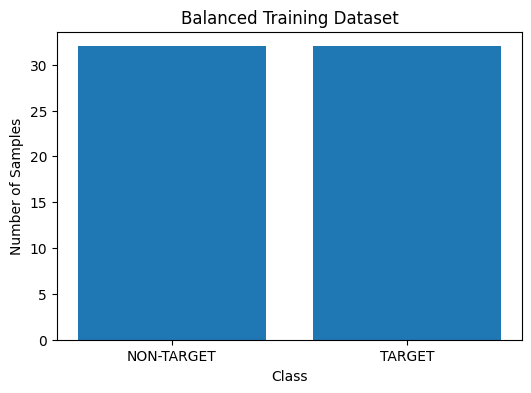

In [ ]:
# ============================================================
# CELL 36: BALANCED CLASS DISTRIBUTION
# ============================================================

# Count each class
balanced_counts = [
    np.sum(y_train_balanced == 0),
    np.sum(y_train_balanced == 1)
]

# Create bar chart
plt.figure(figsize=(6, 4))

plt.bar(
    ["NON-TARGET", "TARGET"],
    balanced_counts
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Balanced Training Dataset")

plt.show()

In [ ]:
# ============================================================
# CELL 37: PREPARE DATA FOR CNN
# ============================================================

# Change:
# (samples, channels, time)
# to:
# (samples, time, channels)

X_train_cnn = np.transpose(
    X_train_balanced,
    (0, 2, 1)
)

X_test_cnn = np.transpose(
    X_test_norm,
    (0, 2, 1)
)

# Print shapes
print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape :", X_test_cnn.shape)

CNN training shape: (64, 120, 70)
CNN testing shape : (48, 120, 70)


In [ ]:
# ============================================================
# CELL 38: CNN + LSTM + FUZZY FEATURE WEIGHTING MODEL
# ============================================================

# Input shape:
# 120 time samples × 64 EEG channels
input_layer = layers.Input(
    shape=(120, 64),
    name="EEG_Input"
)

# ------------------------------------------------------------
# CNN BLOCK 1
# ------------------------------------------------------------

# Extract local EEG features using 32 filters
x = layers.Conv1D(
    filters=32,
    kernel_size=3,
    padding="same",
    name="CNN_Conv1"
)(input_layer)

# Normalize CNN output
x = layers.BatchNormalization(
    name="CNN_BatchNorm1"
)(x)

# Apply ReLU activation
x = layers.Activation(
    "relu",
    name="CNN_ReLU1"
)(x)

# Reduce the time dimension by half
x = layers.MaxPooling1D(
    pool_size=2,
    name="MaxPooling1"
)(x)

# ------------------------------------------------------------
# CNN BLOCK 2
# ------------------------------------------------------------

# Extract deeper EEG features using 64 filters
x = layers.Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    name="CNN_Conv2"
)(x)

# Normalize the output
x = layers.BatchNormalization(
    name="CNN_BatchNorm2"
)(x)

# Apply ReLU activation
x = layers.Activation(
    "relu",
    name="CNN_ReLU2"
)(x)

# ------------------------------------------------------------
# LSTM
# ------------------------------------------------------------

# Learn temporal relationships between EEG features
x = layers.LSTM(
    64,
    return_sequences=True,
    name="LSTM"
)(x)

# ------------------------------------------------------------
# FUZZY MEMBERSHIP
# ------------------------------------------------------------

# Generate fuzzy membership values between 0 and 1
fuzzy_membership = layers.Dense(
    64,
    activation="sigmoid",
    name="Fuzzy_Membership"
)(x)

# ------------------------------------------------------------
# FUZZY FEATURE WEIGHTING
# ------------------------------------------------------------

# Multiply the LSTM features by fuzzy membership values
# This is why we use Functional API instead of Sequential API
fuzzy_features = layers.Multiply(
    name="Fuzzy_Feature_Weight"
)([x, fuzzy_membership])

# ------------------------------------------------------------
# GLOBAL AVERAGE POOLING
# ------------------------------------------------------------

# Convert sequence features into one feature vector
x = layers.GlobalAveragePooling1D(
    name="GlobalAveragePooling"
)(fuzzy_features)

# ------------------------------------------------------------
# FULLY CONNECTED LAYER
# ------------------------------------------------------------

# Learn high-level classification features
x = layers.Dense(
    64,
    activation="relu",
    name="Dense_64"
)(x)

# Reduce overfitting
x = layers.Dropout(
    0.3,
    name="Dropout"
)(x)

# ------------------------------------------------------------
# OUTPUT LAYER
# ------------------------------------------------------------

# Binary classification:
# 1 = Target
# 0 = Non-target
output_layer = layers.Dense(
    1,
    activation="sigmoid",
    name="Target_NonTarget"
)(x)

# ------------------------------------------------------------
# CREATE MODEL
# ------------------------------------------------------------

model = models.Model(
    inputs=input_layer,
    outputs=output_layer,
    name="EEG_CNN_LSTM_Fuzzy"
)

# Display model architecture
model.summary()

Model: "EEG_CNN_LSTM_Fuzzy"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ EEG_Input           │ (None, 120, 64)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_Conv1 (Conv1D)  │ (None, 120, 32)   │      6,176 │ EEG_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_BatchNorm1      │ (None, 120, 32)   │        128 │ CNN_Conv1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_ReLU1           │ (None, 120, 32)   │          0 │ CNN_BatchNorm1[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPooling1         │ (None, 60, 32)    │          0 │ CNN_ReLU1[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_Conv2 (Conv1D)  │ (None, 60, 64)    │      6,208 │ MaxPooling1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_BatchNorm2      │ (None, 60, 64)    │        256 │ CNN_Conv2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_ReLU2           │ (None, 60, 64)    │          0 │ CNN_BatchNorm2[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM (LSTM)         │ (None, 60, 64)    │     33,024 │ CNN_ReLU2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fuzzy_Membership    │ (None, 60, 64)    │      4,160 │ LSTM[0][0]        │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fuzzy_Feature_Weig… │ (None, 60, 64)    │          0 │ LSTM[0][0],       │
│ (Multiply)          │                   │            │ Fuzzy_Membership… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalAveragePooli… │ (None, 64)        │          0 │ Fuzzy_Feature_We… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_64 (Dense)    │ (None, 64)        │      4,160 │ GlobalAveragePoo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout (Dropout)   │ (None, 64)        │          0 │ Dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Target_NonTarget    │ (None, 1)         │         65 │ Dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,177 (211.63 KB)

 Trainable params: 53,985 (210.88 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# ============================================================
# CELL 39: COMPILE MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
# Configure optimizer, loss and accuracy metric

print("Model compiled successfully!")
# Confirmation

Model compiled successfully!


In [ ]:
# ============================================================
# CELL 40: SELECT THE 64 EEG CHANNELS
# ============================================================

# The first 64 channels in this PhysioNet recording are EEG channels
eeg_channel_indices = list(range(64))

# Select only the 64 EEG channels
X_eeg = X[:, eeg_channel_indices, :]

# Display the shape after selecting EEG channels
print("EEG-only X shape:", X_eeg.shape)

# Convert the data from:
# (epochs, channels, time)
# to:
# (epochs, time, channels)
X_model = np.transpose(X_eeg, (0, 2, 1))

# Display the final model input shape
print("Model-ready X shape:", X_model.shape)

EEG-only X shape: (240, 64, 120)
Model-ready X shape: (240, 120, 64)


In [ ]:
# ============================================================
# CELL 41: TRAIN / TEST SPLIT
# ============================================================

# Split the corrected EEG data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the training and testing shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (192, 120, 64)
X_test shape: (48, 120, 64)
y_train shape: (192,)
y_test shape: (48,)


In [ ]:
# ============================================================
# CELL 42: FINAL CHECK BEFORE TRAINING
# ============================================================

print("Model expected input:", model.input_shape)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

if model.input_shape[1:] == X_train.shape[1:]:
    print("\nShape matched! Ready for training.")
else:
    print("\nShape mismatch! Do not train.")

Model expected input: (None, 120, 64)
Training data shape: (192, 120, 64)
Testing data shape: (48, 120, 64)

Shape matched! Ready for training.


In [ ]:
# ============================================================
# CELL 43: RECREATE THE CNN-LSTM-FUZZY MODEL
# ============================================================

# Clear the previous TensorFlow model/session state
tf.keras.backend.clear_session()

# Create the input layer
input_layer = layers.Input(
    shape=(120, 64),
    name="EEG_Input"
)

# ------------------------------------------------------------
# CNN BLOCK 1
# ------------------------------------------------------------

x = layers.Conv1D(
    filters=32,
    kernel_size=3,
    padding="same",
    name="CNN_Conv1"
)(input_layer)

x = layers.BatchNormalization(
    name="CNN_BatchNorm1"
)(x)

x = layers.Activation(
    "relu",
    name="CNN_ReLU1"
)(x)

x = layers.MaxPooling1D(
    pool_size=2,
    name="MaxPooling1"
)(x)

# ------------------------------------------------------------
# CNN BLOCK 2
# ------------------------------------------------------------

x = layers.Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    name="CNN_Conv2"
)(x)

x = layers.BatchNormalization(
    name="CNN_BatchNorm2"
)(x)

x = layers.Activation(
    "relu",
    name="CNN_ReLU2"
)(x)

# ------------------------------------------------------------
# LSTM
# ------------------------------------------------------------

x = layers.LSTM(
    64,
    return_sequences=True,
    name="LSTM"
)(x)

# ------------------------------------------------------------
# FUZZY MEMBERSHIP
# ------------------------------------------------------------

fuzzy_membership = layers.Dense(
    64,
    activation="sigmoid",
    name="Fuzzy_Membership"
)(x)

# Multiply LSTM features with fuzzy membership weights
fuzzy_features = layers.Multiply(
    name="Fuzzy_Feature_Weight"
)([x, fuzzy_membership])

# ------------------------------------------------------------
# CLASSIFICATION
# ------------------------------------------------------------

x = layers.GlobalAveragePooling1D(
    name="GlobalAveragePooling"
)(fuzzy_features)

x = layers.Dense(
    64,
    activation="relu",
    name="Dense_64"
)(x)

x = layers.Dropout(
    0.3,
    name="Dropout"
)(x)

# Final binary output:
# 0 = NON-TARGET
# 1 = TARGET
output_layer = layers.Dense(
    1,
    activation="sigmoid",
    name="Target_NonTarget"
)(x)

# Create the complete model
model = models.Model(
    inputs=input_layer,
    outputs=output_layer,
    name="EEG_CNN_LSTM_Fuzzy"
)

print("Model recreated successfully!")
print("Model input shape:", model.input_shape)

Model recreated successfully!
Model input shape: (None, 120, 64)


In [ ]:
# ============================================================
# CELL 44: COMPILE THE NEW MODEL
# ============================================================

# Configure the optimizer, loss function and evaluation metric
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# ============================================================
# CELL 45: FINAL CHECK BEFORE TRAINING
# ============================================================

print("Model expected input:", model.input_shape)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

if model.input_shape[1:] == X_train.shape[1:]:
    print("\nShape matched! Ready for training.")
else:
    print("\nShape mismatch! Do not train.")

Model expected input: (None, 120, 64)
Training data shape: (192, 120, 64)
Testing data shape: (48, 120, 64)

Shape matched! Ready for training.


In [ ]:
# ============================================================
# CELL 46: TRAIN THE MODEL
# ============================================================

# Train the CNN-LSTM-Fuzzy model
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

print("\nTraining completed successfully!")

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.6993 - loss: 0.6871 - val_accuracy: 0.7692 - val_loss: 0.6796
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8497 - loss: 0.6650 - val_accuracy: 0.7692 - val_loss: 0.6532
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8497 - loss: 0.6163 - val_accuracy: 0.7692 - val_loss: 0.5820
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8497 - loss: 0.4741 - val_accuracy: 0.7692 - val_loss: 0.5803
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8497 - loss: 0.4335 - val_accuracy: 0.7692 - val_loss: 0.6245
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8497 - loss: 0.4426 - val_accuracy: 0.7692 - val_loss: 0.5759
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8497 - loss: 0.4383 - val_accuracy: 0.7692 - val_loss: 0.5497
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8497 - loss: 0.4397 - val_accuracy: 0.7692 - val_loss: 0.5480

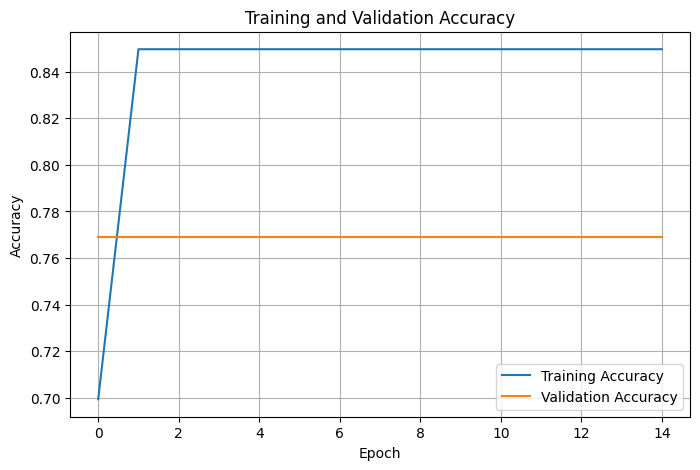

In [ ]:
# ============================================================
# CELL 47: TRAINING AND VALIDATION ACCURACY
# ============================================================

# Create a graph
plt.figure(figsize=(8, 5))

# Plot training accuracy
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

# Plot validation accuracy
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

# Add graph details
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Show legend
plt.legend()

# Show grid
plt.grid(True)

# Display the graph
plt.show()

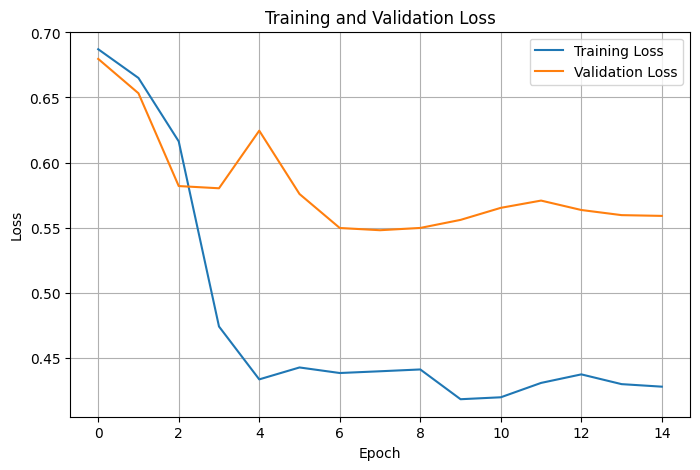

In [ ]:
# ============================================================
# CELL 48: TRAINING AND VALIDATION LOSS
# ============================================================

# Create a graph
plt.figure(figsize=(8, 5))

# Plot training loss
plt.plot(
    history.history["loss"],
    label="Training Loss"
)

# Plot validation loss
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

# Add graph details
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Show legend
plt.legend()

# Show grid
plt.grid(True)

# Display the graph
plt.show()

In [ ]:
# ============================================================
# CELL 49: TEST SET EVALUATION
# ============================================================

# Evaluate the trained model using completely separate test data
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

# Display the results
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8333 - loss: 0.4510 

Test Loss: 0.4509614408016205
Test Accuracy: 0.8333333134651184


In [ ]:
# ============================================================
# CELL 50: GENERATE TEST SET PREDICTIONS
# ============================================================

# Predict the probability for every EEG epoch in the test set
y_probability = model.predict(
    X_test,
    verbose=1
)

# Convert probability into a class label
# Probability >= 0.5  -> TARGET (1)
# Probability < 0.5   -> NON-TARGET (0)
y_pred = (y_probability >= 0.5).astype(int).flatten()

print("\nPredicted labels:")
print(y_pred)

print("\nActual labels:")
print(y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 462ms/step

Predicted labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0]

Actual labels:
[0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0
 0 1 1 0 0 0 0 0 0 0 0]


In [ ]:
# ============================================================
# CELL 51: PREDICTION ACCURACY
# ============================================================

# Calculate how many predictions are correct
prediction_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Prediction Accuracy:", prediction_accuracy)
print("Prediction Accuracy (%):", prediction_accuracy * 100)

Prediction Accuracy: 0.8333333333333334
Prediction Accuracy (%): 83.33333333333334


In [ ]:
# ============================================================
# CELL 52: CLASSIFICATION REPORT
# ============================================================

# Generate detailed performance metrics
report = classification_report(
    y_test,
    y_pred,
    target_names=["NON-TARGET", "TARGET"]
)

print(report)

              precision    recall  f1-score   support

  NON-TARGET       0.83      1.00      0.91        40
      TARGET       0.00      0.00      0.00         8

    accuracy                           0.83        48
   macro avg       0.42      0.50      0.45        48
weighted avg       0.69      0.83      0.76        48



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix:
[[40  0]
 [ 8  0]]


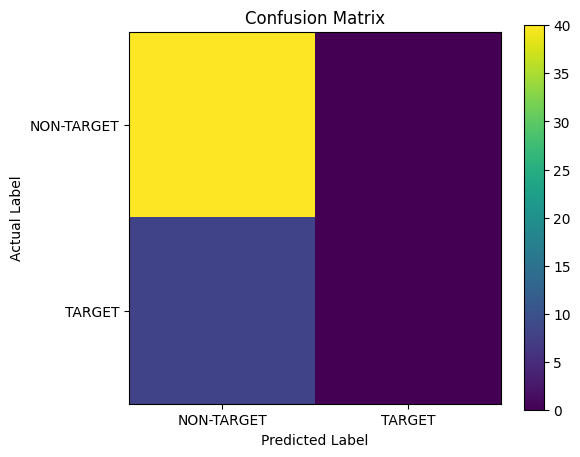

In [ ]:
# ============================================================
# CELL 53: CONFUSION MATRIX
# ============================================================

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix as an image
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["NON-TARGET", "TARGET"]
)

plt.yticks(
    [0, 1],
    ["NON-TARGET", "TARGET"]
)

plt.colorbar()

plt.show()

In [ ]:
# ============================================================
# CELL 54: SINGLE EEG EPOCH PREDICTION
# ============================================================

# Select the first EEG epoch from the test set
sample_index = 0

sample = X_test[
    sample_index:sample_index + 1
]

# Predict the probability of TARGET
probability = model.predict(
    sample,
    verbose=0
)[0][0]

# Convert probability into TARGET / NON-TARGET
if probability >= 0.5:
    prediction = "TARGET"
else:
    prediction = "NON-TARGET"

print("Predicted probability:", probability)
print("Predicted class:", prediction)

# Display the actual class
if y_test[sample_index] == 1:
    actual_class = "TARGET"
else:
    actual_class = "NON-TARGET"

print("Actual class:", actual_class)

Predicted probability: 0.15630105
Predicted class: NON-TARGET
Actual class: NON-TARGET


In [ ]:
# ============================================================
# CELL 55: CREATE SMART HOME APPLIANCES
# ============================================================

# Define the appliances available in our smart home
appliances = [
    "LIGHT",
    "FAN",
    "TV",
    "AC",
    "DOOR",
    "MUSIC"
]

# Initially, all appliances are OFF
appliance_state = {
    appliance: "OFF"
    for appliance in appliances
}

# Display the initial state
print("Initial Smart Home State:")

for appliance, state in appliance_state.items():
    print(appliance, "->", state)

Initial Smart Home State:
LIGHT -> OFF
FAN -> OFF
TV -> OFF
AC -> OFF
DOOR -> OFF
MUSIC -> OFF


In [ ]:
# ============================================================
# CELL 56: DISPLAY EEG PREDICTION RESULT
# ============================================================

# Display the probability predicted by the CNN-LSTM-Fuzzy model
print("TARGET probability:", probability)

# Display the final EEG classification
print("EEG Prediction:", prediction)

# Explain the prediction
if prediction == "TARGET":
    print("\nP300 TARGET detected.")
    print("A user command can be generated.")
else:
    print("\nNON-TARGET detected.")
    print("No appliance command is generated.")

TARGET probability: 0.15630105
EEG Prediction: NON-TARGET

NON-TARGET detected.
No appliance command is generated.


In [ ]:
# ============================================================
# CELL 57: P300 COMMAND TO SMART HOME APPLIANCE
# ============================================================

# Define the appliance currently selected in the BCI interface
# In the real system, this comes from the visual interface
selected_appliance = "LIGHT"

# Create the smart-home state
appliance_state = {
    "LIGHT": "OFF",
    "FAN": "OFF",
    "TV": "OFF",
    "AC": "OFF",
    "DOOR": "OFF",
    "MUSIC": "OFF"
}

# Check the EEG model prediction
if prediction == "TARGET":

    # Turn all appliances OFF first
    for appliance in appliance_state:
        appliance_state[appliance] = "OFF"

    # Turn the selected appliance ON
    appliance_state[selected_appliance] = "ON"

    print("P300 TARGET detected.")
    print("Command generated for:", selected_appliance)

else:

    # No command is generated for NON-TARGET
    print("NON-TARGET detected.")
    print("No appliance command generated.")

# Display the final smart-home state
print("\nSmart Home State:")

for appliance, state in appliance_state.items():
    print(appliance, "->", state)

NON-TARGET detected.
No appliance command generated.

Smart Home State:
LIGHT -> OFF
FAN -> OFF
TV -> OFF
AC -> OFF
DOOR -> OFF
MUSIC -> OFF


In [ ]:
# ============================================================
# CELL 58: BCI APPLIANCE SELECTION
# ============================================================

# List of appliances available in the smart home
appliances = [
    "LIGHT",
    "FAN",
    "TV",
    "AC",
    "DOOR",
    "MUSIC"
]

# Select the appliance represented by the current BCI target
# In the final application, this will come from the visual interface
selected_appliance_index = 0

selected_appliance = appliances[selected_appliance_index]

print("Available appliances:")
for i, appliance in enumerate(appliances):
    print(i, "->", appliance)

print("\nCurrently selected appliance:", selected_appliance)

Available appliances:
0 -> LIGHT
1 -> FAN
2 -> TV
3 -> AC
4 -> DOOR
5 -> MUSIC

Currently selected appliance: LIGHT


In [ ]:
# ============================================================
# CELL 59: CHANGE BCI TARGET APPLIANCE
# ============================================================

# Change the selected appliance index
# Example: 1 means FAN
selected_appliance_index = 1

# Get the corresponding appliance
selected_appliance = appliances[selected_appliance_index]

print("BCI target appliance:", selected_appliance)

BCI target appliance: FAN


In [ ]:
# ============================================================
# CELL 60: APPLY EEG COMMAND TO SMART HOME
# ============================================================

# Start with all appliances OFF
appliance_state = {
    appliance: "OFF"
    for appliance in appliances
}

# Apply the EEG prediction
if prediction == "TARGET":

    # Turn every appliance OFF first
    for appliance in appliance_state:
        appliance_state[appliance] = "OFF"

    # Turn ON only the selected appliance
    appliance_state[selected_appliance] = "ON"

    print("TARGET detected.")
    print("Command sent to:", selected_appliance)

else:

    # NON-TARGET means no appliance command
    print("NON-TARGET detected.")
    print("No appliance command generated.")

# Display final state
print("\nFinal Smart Home State:")

for appliance, state in appliance_state.items():
    print(appliance, "->", state)

NON-TARGET detected.
No appliance command generated.

Final Smart Home State:
LIGHT -> OFF
FAN -> OFF
TV -> OFF
AC -> OFF
DOOR -> OFF
MUSIC -> OFF


In [ ]:
# ============================================================
# CELL 61: SMART-HOME ON/OFF LOGIC
# ============================================================

# Six appliances used in our smart-home prototype
appliances = [
    "Light",
    "Fan",
    "TV",
    "AC",
    "Music System",
    "Door"
]

# Initially, all appliances are OFF
appliance_state = {
    appliance: 0
    for appliance in appliances
}

# ------------------------------------------------------------
# FUNCTION 1: Turn ON exactly one appliance
# ------------------------------------------------------------

def turn_on_appliance(selected_appliance):

    # Check whether the appliance name is valid
    if selected_appliance not in appliance_state:
        print("Invalid appliance command.")
        return

    # First turn OFF every appliance
    for appliance in appliance_state:
        appliance_state[appliance] = 0

    # Then turn ON only the selected appliance
    appliance_state[selected_appliance] = 1

    print("\nSmart-home state updated:")

    for appliance, state in appliance_state.items():
        if state == 1:
            print(appliance, "-> ON")
        else:
            print(appliance, "-> OFF")


# ------------------------------------------------------------
# FUNCTION 2: Check whether the state is valid
# ------------------------------------------------------------

def check_appliance_state():

    # Count how many appliances are currently ON
    number_of_on_appliances = sum(appliance_state.values())

    # Exactly one appliance must be ON
    if number_of_on_appliances == 1:
        print("\nVALID STATE: Exactly one appliance is ON.")

    elif number_of_on_appliances == 0:
        print("\nINVALID STATE: No appliance is ON.")

    else:
        print("\nINVALID STATE: Multiple appliances are ON.")


# ------------------------------------------------------------
# TEST THE ON/OFF LOGIC
# ------------------------------------------------------------

# Example: BCI command selects the Light
turn_on_appliance("Light")

# Check the resulting state
check_appliance_state()


Smart-home state updated:
Light -> ON
Fan -> OFF
TV -> OFF
AC -> OFF
Music System -> OFF
Door -> OFF

VALID STATE: Exactly one appliance is ON.


In [ ]:
# ============================================================
# CELL 62: USE ACTUAL EEG MODEL PREDICTION
# ============================================================

# Use one real EEG epoch from our test dataset
sample_index = 0

single_eeg = X_test[sample_index:sample_index + 1]

# Get prediction from the trained CNN + LSTM + Fuzzy model
prediction_probability = model.predict(single_eeg, verbose=0)[0][0]

# Convert probability into TARGET / NON-TARGET
if prediction_probability >= 0.5:
    eeg_prediction = "TARGET"
else:
    eeg_prediction = "NON-TARGET"

print("EEG Prediction Probability:", round(float(prediction_probability), 4))
print("EEG Prediction:", eeg_prediction)

EEG Prediction Probability: 0.1563
EEG Prediction: NON-TARGET


In [ ]:
# ============================================================
# CELL 63: CONNECT EEG PREDICTION TO SMART-HOME COMMAND
# ============================================================

# Check the actual prediction obtained from EEG
if eeg_prediction == "TARGET":

    print("TARGET detected from EEG.")
    print("BCI command can be accepted.")

else:

    print("NON-TARGET detected from EEG.")
    print("No appliance command generated.")

NON-TARGET detected from EEG.
No appliance command generated.


In [ ]:
# ============================================================
# CELL 64: APPLY EEG COMMAND TO SMART-HOME
# ============================================================

# If EEG detects NON-TARGET, do not change appliance states
if eeg_prediction == "NON-TARGET":

    print("NON-TARGET detected.")
    print("No appliance command applied.")
    print("Current smart-home state:")

    for appliance, state in appliance_state.items():
        if state == 1:
            print(appliance, "-> ON")
        else:
            print(appliance, "-> OFF")


# If EEG detects TARGET, a valid BCI command is available
else:

    print("TARGET detected.")
    print("A valid BCI command is available.")
    print("Waiting for the decoded appliance command...")

NON-TARGET detected.
No appliance command applied.
Current smart-home state:
Light -> ON
Fan -> OFF
TV -> OFF
AC -> OFF
Music System -> OFF
Door -> OFF


In [ ]:
# ============================================================
# CELL 65: TEST SMART-HOME COMMAND LOGIC
# ============================================================

# Example BCI command for testing the application layer
# This is NOT changing the EEG prediction.
test_command = "Fan"

# Apply the command
turn_on_appliance(test_command)

# Check whether the resulting state is valid
check_appliance_state()


Smart-home state updated:
Light -> OFF
Fan -> ON
TV -> OFF
AC -> OFF
Music System -> OFF
Door -> OFF

VALID STATE: Exactly one appliance is ON.


In [ ]:
# ============================================================
# CELL 66: BCI COMMAND MAPPING
# ============================================================

# Prototype mapping between BCI commands and appliances
command_to_appliance = {
    "CMD1": "Light",
    "CMD2": "Fan",
    "CMD3": "TV",
    "CMD4": "AC",
    "CMD5": "Music System",
    "CMD6": "Door"
}

# Display the available prototype commands
for command, appliance in command_to_appliance.items():
    print(command, "->", appliance)

CMD1 -> Light
CMD2 -> Fan
CMD3 -> TV
CMD4 -> AC
CMD5 -> Music System
CMD6 -> Door


In [ ]:
# ============================================================
# CELL 67: APPLY BCI COMMAND
# ============================================================

# Example decoded BCI command from the application layer
decoded_command = "CMD2"

# Convert command into the corresponding appliance
selected_appliance = command_to_appliance[decoded_command]

# Turn ON the selected appliance and OFF all others
turn_on_appliance(selected_appliance)


Smart-home state updated:
Light -> OFF
Fan -> ON
TV -> OFF
AC -> OFF
Music System -> OFF
Door -> OFF


In [ ]:
# ============================================================
# CELL 68: FINAL PROTOTYPE STATUS
# ============================================================

print("========== SMART HOME BCI ==========")

# Show the decoded command and selected appliance
print("BCI Command:", decoded_command)
print("Selected Appliance:", selected_appliance)

# Display the final ON/OFF status
print("\nAppliance Status:")

for appliance, state in appliance_state.items():
    status = "ON" if state == 1 else "OFF"
    print(appliance, "->", status)

========== SMART HOME BCI ==========
BCI Command: CMD2
Selected Appliance: Fan

Appliance Status:
Light -> OFF
Fan -> ON
TV -> OFF
AC -> OFF
Music System -> OFF
Door -> OFF
